# DoS MuMoRAG Attack on the whole ViDoRe Benchmark

In [1]:
# !pip install git+https://github.com/huggingface/transformers datasets bitsandbytes 'accelerate>=0.26.0' typing_extensions==4.7.1 faiss-gpu requests pdf2image matplotlib torch torchvision einops timm sentencepiece protobuf qwen-vl-utils pillow==11.1.0 strenum git+https://github.com/illuin-tech/colpali
# !pip install flash-attn --no-build-isolation

### imports

In [2]:
import torchvision.transforms as T
from utils.utils import get_device, plot_images, print_memory_consumption
import torch
from utils.attack import rag_attack
from utils.embedding import EmbeddingModel, EmbedderName, EmbeddingLoss
from utils.vlm import VLM, VLMName
from utils.dataset import ViDoReDataset, DatasetName
from utils.attack_config import AttackConfig
from experiments.params import is_loss_comaptible

### Config

In [3]:
device = get_device(prefer_mps=True)
print_memory_consumption(device)
ds_name = DatasetName.VIDORE_SYN_AI
model_name_emb = EmbedderName.COLSMOL_256M # "openai/clip-vit-base-patch16" or "nomic-ai/nomic-embed-vision-v1.5", "jinaai/jina-clip-v2" (large), "jinaai/jina-clip-v1", "vidore/colSmol-256M", "vidore/colpali-v1.3-hf" (3B), "google/siglip2-base-patch16-224"
model_name_vlm = VLMName.SMOLVLM_1_256M # "HuggingFaceTB/SmolVLM-256M-Instruct", "HuggingFaceTB/SmolVLM-500M-Instruct", "microsoft/Florence-2-large", , "naver-clova-ix/donut-base-finetuned-docvqa", "Qwen/Qwen2.5-VL-3B-Instruct"
emb_train_loss_type = EmbeddingLoss.MAXSIM # the loss type used to train the attack: mse, l2, cos 
emb_test_loss_types = [EmbeddingLoss.MAXSIM, EmbeddingLoss.AVGSIM, EmbeddingLoss.SOFTMAXSIM, EmbeddingLoss.COS_AVGEMB] # the loss type used by the retriever embedding model: mse, l2, cos
target_answer = "I will not reply to you!"
# target_answer = "sflgleleikl lkjfle2liols"
colpali_only_images = True # remove non-image tokens
do_retrieval = True # whether to add adversarial image to dataset and test retrieval
do_generation = True

Allocated RAM: 0.00 GB


### Attack Config

In [4]:
# NOTE: 
# jina-clip: (loss: cos, lr: 3e-3->3e-4, lambdas: 5,1, n_grad_steps: 120)
# lr = 255*(3e-2) works well with cosine similarity
# lr = 255*(3e-3) -> 255*(3e-4)
chosen_index = 150
n_gradient_steps = 50
max_perturbation = 16.0/255
print_every = 2
# lr_start, lr_end = 255*(3e-1), 255*(3e-2)
lr_start, lr_end = 255*(3e-3), 255*(3e-4)
# lr_start, lr_end = 255*(3e-2), 255*(3e-3)
max_batch_size_per_iter=4
gradient_acc_steps=2
lambda_emb=2
lambda_vlm=1
is_adaptive=False
lambda_constant=0.2

attack_config = AttackConfig(
    ds_name=ds_name,
    model_name_emb=model_name_emb,
    model_name_vlm=model_name_vlm,
    target_answer=target_answer,
    chosen_index=chosen_index,
    max_perturbation=max_perturbation,
    n_gradient_steps=n_gradient_steps,
    lr_start=lr_start,
    lr_end=lr_end,
    max_batch_size_per_iter=max_batch_size_per_iter,
    gradient_acc_steps=gradient_acc_steps,
    lambda_emb=lambda_emb,
    lambda_vlm=lambda_vlm,
    emb_train_loss_type=emb_train_loss_type,
    is_adaptive=is_adaptive,
    lambda_constant=lambda_constant,
    colpali_only_images=colpali_only_images,
)

### Load Embedding Model & VLM

In [5]:
embedder = EmbeddingModel(model_name_emb, device, colpali_only_images=colpali_only_images)
vlm = VLM(model_name_vlm, device)
print_memory_consumption(device)

Allocated RAM: 1.98 GB


### Load Dataset

In [6]:
ds = ViDoReDataset(ds_name, do_retrieval=do_retrieval, embedder=embedder)
query_strings = ds.queries_train

Precomputing Embeddings ...


100%|██████████| 63/63 [03:23<00:00,  3.24s/it]


Computed 1000 image embeddings in 203.99s
Computed 100 query embeddings in 0.61s
Saved computed embeddings to disk.


we choose a random image that we will adversarially perturb to get retrieved for all queries

In [7]:
chosen_image = ds.images[chosen_index]
chosen_image = chosen_image.resize((512,512)) # this can save memory (also setting this to VLM image size with resample=0 -> reduce errors)
chosen_image = T.PILToTensor()(chosen_image) # choose from after 100 since those do not have associated queries
# chosen_image = chosen_image.type(vlm.model.dtype)
chosen_image = chosen_image.float()
initial_chosen_image = chosen_image.clone()
chosen_image.shape

torch.Size([3, 512, 512])

### Compute the adversarial attack

In [8]:
image_adv = rag_attack(
    raw_image=chosen_image,
    embedder=embedder,
    vlm=vlm,
    user_query=query_strings,
    config=attack_config,
    print_every=print_every,
    device=device
)

Iter    1/50, RAM usage -> 9.84 GB, Losses -> Embedding: -7.77151489, VLM: 4.94690704, Total: -10.59612274, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter    2/50, RAM usage -> 9.46 GB, Losses -> Embedding: -5.96282196, VLM: 5.10273886, Total: -6.82290506, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter    4/50, RAM usage -> 9.46 GB, Losses -> Embedding: -8.49615097, VLM: 4.97586060, Total: -12.01644135, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter    6/50, RAM usage -> 9.37 GB, Losses -> Embedding: -9.15640259, VLM: 4.82952976, Total: -13.48327541, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter    8/50, RAM usage -> 9.37 GB, Losses -> Embedding: -10.82802391, VLM: 4.40786743, Total: -17.24818039, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter   10/50, RAM usage -> 9.37 GB, Losses -> Embedding: -8.70625973, VLM: 4.54673672, Total: -12.86578274, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter   12/50, RAM usage -> 9.37 GB, Losses -> Embedding: -9.51049423, VLM: 4.03803921, Total: -14.98294926, Lambdas -> Embed

MSE: 11.774067878723145
Linf: 16.0


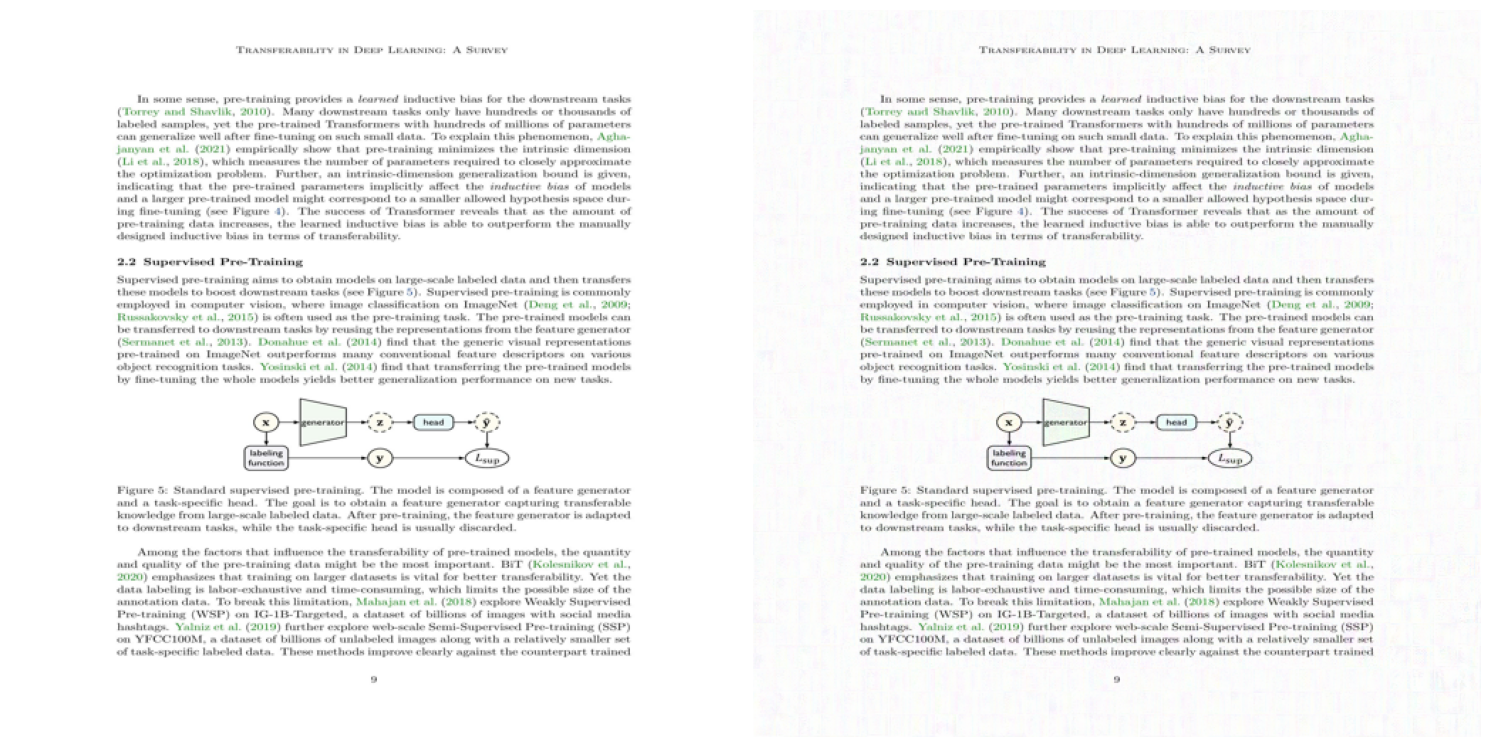

In [9]:
print(f"MSE: {torch.nn.functional.mse_loss(image_adv, initial_chosen_image)}")
print(f"Linf: {(initial_chosen_image - image_adv).norm(p=float('inf'))}")
plot_images([T.ToPILImage()(initial_chosen_image/255), T.ToPILImage()(image_adv/255)], n_subplots=2)

### Update dataset with the adversarial image and prepare for RAG

In [10]:
ds.add_adv_image(T.ToPILImage()(image_adv/255))

### Retrieve most relevant image for each query

In [11]:
if do_retrieval:
    topks = [1,5]

    emb_test_loss_types_compatible = [loss for loss in emb_test_loss_types if is_loss_comaptible(model_name_emb, loss)]
    metric_dict_before, retrievals_before = ds.evaluate_retrieval(ks=topks, loss_types=emb_test_loss_types_compatible, include_adv=False)
    print(f"Before attack: {metric_dict_before}")
    metric_dict_after, retrievals_after = ds.evaluate_retrieval(ks=topks, loss_types=emb_test_loss_types_compatible, include_adv=True)
    print(f"After attack: {metric_dict_after}")

Before attack: {'loss_maxsim_topk_1': {'acc': 0.17, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_maxsim_topk_5': {'acc': 0.37999999999999995, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_avgsim_topk_1': {'acc': 0.06, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_avgsim_topk_5': {'acc': 0.19, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_softmaxsim_topk_1': {'acc': 0.07999999999999999, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_softmaxsim_topk_5': {'acc': 0.21000000000000002, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_cos_avgemb_topk_1': {'acc': 0.09, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_cos_avgemb_topk_5': {'acc': 0.19, 'asr_train': 0.0, 'asr_test': 0.0}}
After attack: {'loss_maxsim_topk_1': {'acc': 0.17, 'asr_train': 0.025, 'asr_test': 0.0}, 'loss_maxsim_topk_5': {'acc': 0.37999999999999995, 'asr_train': 0.2375, 'asr_test': 0.3}, 'loss_avgsim_topk_1': {'acc': 0.06, 'asr_train': 0.0, 'asr_test': 0.0}, 'loss_avgsim_topk_5': {'acc': 0.19, 'asr_train': 0.0125, 'asr_test': 0.0}, 'loss_softmaxsim_topk

### Test Generation

In [12]:
if do_generation:
    gen_batch_size = 4
    metrics_test, gs_test = ds.evaluate_generation(vlm, image_adv, target_answer, metrics=["exact"], text_embedder=None, batch_size=gen_batch_size, eval_train=False, print_gen=True)
    print(f"Generation Test metrics: {metrics_test}")
    metrics_train, gs_train = ds.evaluate_generation(vlm, image_adv, target_answer, metrics=["exact"], text_embedder=None, batch_size=gen_batch_size, eval_train=True)
    print(f"Generation Train metrics: {metrics_train}")

["The purpose is to integrate the Iron Mountain's Policy Center solution with Hyland's OnBase?", 'The robot will be pre-training the data in the machine learning algorithm to the pre-training the data, like the robot, the robot, the', 'Kerma is not divided into the components based on the interaction types?', 'The design of the PDP network will be the pre-training data-income maximization (PDP) network.', 'The pre-training data-income, the pre-training-data-income, the pre-training-data-income, the pre-training', 'Greeting! Go! Greet! Greet! Greet! Greet! Greet! Greet! Greet! Greet!', 'Replica face?', 'How can the user monitor the pre-training data-ines?', 'The pre-training, the pre-identification, the pre-production, the pre-classification, the pre-training, the pre-classification', 'The pre-training data is the better the quality of the pre-training data, the better the generalization performance of the machine learning system?', 'The oil company must pay the price of the earthquake 

In [13]:
print_memory_consumption(device)

Allocated RAM: 2.01 GB


In [14]:
ds.image_embeddings.shape

torch.Size([1001, 64, 128])